In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [44]:
df = pd.read_csv("../Data/dataset.csv")
df.isnull().sum()

category_1           0
category_2           0
category_3           0
title               18
product_rating      80
selling_price       28
mrp                375
seller_name        216
seller_rating      214
description       7020
highlights        5481
image_links          0
dtype: int64

In [45]:
# Check Duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [46]:
# Inspect Price Columns
df['selling_price'] = (
    df['selling_price']
    .astype(str)
    .str.replace("₹","")
    .str.replace(",","")
)
df['selling_price'] = pd.to_numeric(
    df['selling_price']
    )

In [47]:
df['mrp'].head()

0    ₹4,000
1      ₹600
2      ₹199
3      ₹299
4    ₹1,399
Name: mrp, dtype: str

In [48]:
# Inspect MRP Columns
df['mrp'] = (
    df['mrp'].astype(str)
    .str.replace('₹','')
    .str.replace(',','')
)

df['mrp'] = pd.to_numeric(
    df['mrp']
)

In [49]:
# Data Types Verification
df.info()

<class 'pandas.DataFrame'>
Index: 12004 entries, 0 to 12040
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category_1      12004 non-null  str    
 1   category_2      12004 non-null  str    
 2   category_3      12004 non-null  str    
 3   title           11986 non-null  str    
 4   product_rating  11924 non-null  float64
 5   selling_price   11976 non-null  float64
 6   mrp             11629 non-null  float64
 7   seller_name     11788 non-null  str    
 8   seller_rating   11790 non-null  float64
 9   description     5020 non-null   str    
 10  highlights      6556 non-null   str    
 11  image_links     12004 non-null  str    
dtypes: float64(4), str(8)
memory usage: 1.2 MB


In [50]:
# Dis Percentage Col
df['discount_percentage'] = (
    (df['mrp'] - df['selling_price']) / df['mrp']
) * 100

In [51]:
# Check
df[['mrp','selling_price','discount_percentage']].head()

,mrp,selling_price,discount_percentage
0,4000.0,1615.0,59.625000
1,600.0,152.0,74.666667
2,199.0,59.0,70.351759
3,299.0,75.0,74.916388
4,1399.0,329.0,76.483202


# Save Cleaned Dataset

In [52]:
df.to_csv("../Data/dataset.csv",index = False)

In [57]:
# Missing Values Analysis
df.isnull().sum().sort_values(ascending=False)

description            6984
highlights             5448
mrp                     375
discount_percentage     375
seller_name             216
seller_rating           214
product_rating           80
selling_price            28
title                    18
category_2                0
category_3                0
category_1                0
image_links               0
dtype: int64

In [58]:
# Create Missing Values Percentages
missing = (df.isnull().sum()/len(df)*100)
missing.sort_values(ascending=False)

description            58.180606
highlights             45.384872
mrp                     3.123959
discount_percentage     3.123959
seller_name             1.799400
seller_rating           1.782739
product_rating          0.666445
selling_price           0.233256
title                   0.149950
category_2              0.000000
category_3              0.000000
category_1              0.000000
image_links             0.000000
dtype: float64

In [63]:
df[['selling_price','mrp','product_rating',
    'seller_rating','discount_percentage']].describe()

,selling_price,mrp,product_rating,seller_rating,discount_percentage
count,11976.000000,1.162900e+04,11924.000000,11790.000000,11629.000000
mean,1742.869322,3.177014e+03,4.061565,4.394156,54.601902
std,7798.774118,1.445363e+04,0.346020,0.404488,21.580057
min,10.000000,6.500000e+01,1.000000,3.000000,0.002857
25%,289.000000,7.500000e+02,3.900000,4.100000,40.038132
50%,439.000000,1.199000e+03,4.100000,4.400000,58.506543
75%,799.000000,1.999000e+03,4.300000,4.700000,72.036018
max,300490.000000,1.174131e+06,5.000000,5.000000,95.547310


In [64]:
#Top categories by product count

category_count = (
    df['category_1'].value_counts().head()
)
category_count

category_1
Women's wear              2413
Men's wear                2343
Bady and Kids             2327
Home and Furniture        2120
Sports, Books and More    1820
Name: count, dtype: int64

# Visualization

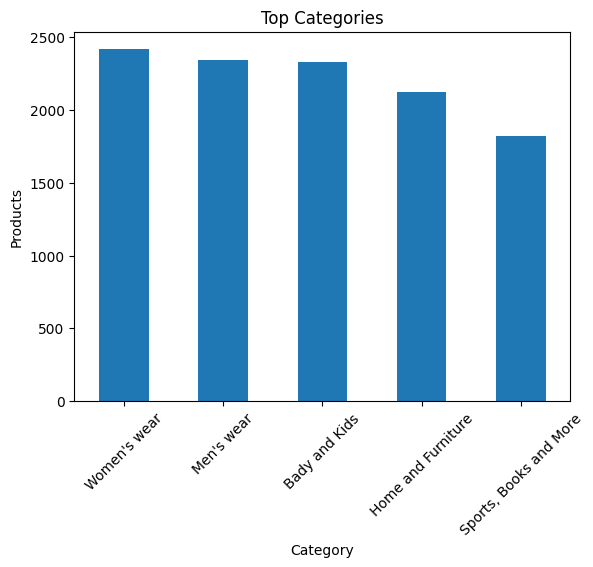

In [80]:
plt.Figure(figsize=(10,5))

category_count.plot(kind='bar')

plt.title("Top Categories")
plt.xlabel("Category")
plt.ylabel("Products")
plt.xticks(rotation=45)

plt.show()

In [81]:
# 10 Most expensive products

top_products = (
    df[['title','selling_price']]
    .sort_values(
        by='selling_price',
        ascending=False
    )
    .head()
)
top_products

,title,selling_price
2328,DELL Allienware Core i7 12th Gen - (32 GB/1 TB...,300490.0
2683,"SONY SEL100400GMC Lens (White, 100 - 400 mm)",199690.0
2337,APPLE iMac Core i5 (7th Gen) (8 GB DDR4/1 TB/M...,189990.0
2334,APPLE All-in-One Core i5 (6th Gen) (8 GB DDR3/...,180990.0
2703,"SONY SEL200600G Lens (White, 200 - 600 mm)",154890.0


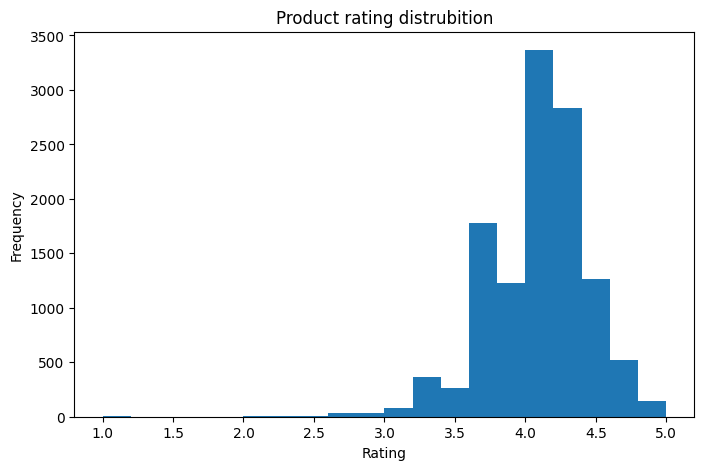

In [ ]:
#Product rating dist

plt.figure(figsize=(8,5))
plt.hist(
    df['product_rating'].dropna(),
    bins=20
)
plt.title('Product rating distrubition')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

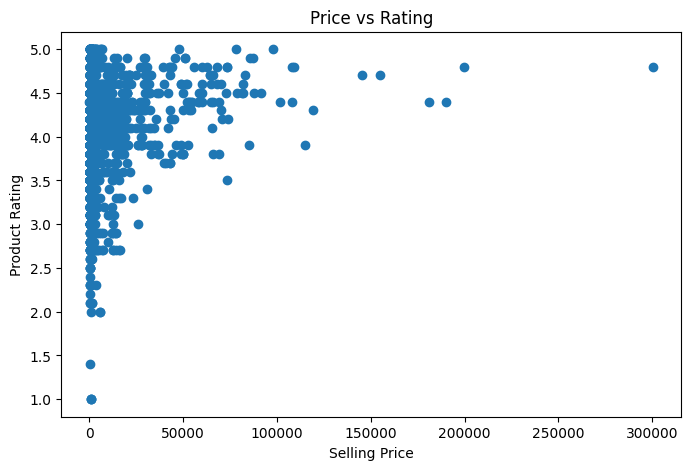

In [84]:
#Price VS Rating analysis

plt.figure(figsize=(8,5))

plt.scatter(
    df['selling_price'],
    df['product_rating']
)

plt.xlabel('Selling Price')
plt.ylabel('Product Rating')
plt.title('Price vs Rating')

plt.show()